# Exploración de los datos

## Antes de empezar

### Requisitos para ejecutar este Notebook

Para garantizar la correcta ejecución del código y la reproducibilidad de los resultados, es necesario contar con un entorno de Python configurado con las siguientes dependencias.

### Versión de Python

Se recomienda utilizar:

- **Python ≥ 3.10**  
- Probado en **Python 3.14**

### Librerías necesarias

Instalar las siguientes librerías antes de ejecutar el notebook:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl



## 1. Importar las librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np
import math

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols

from statsmodels.stats.diagnostic import linear_rainbow
from scipy.stats import ttest_1samp
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro


## 2. Cargar datos

Cargar los datos del csv

In [2]:
datos_pacientes = pd.read_csv('./data/Datos Lab 1.csv')

Trabajar sobre una copia de los datos

In [3]:
datos = datos_pacientes.copy()

Qué representan los datos compartidos

In [4]:
datos.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


## 3. Perfilamiento

Se usa la función head() para tomar una muestra de los primero datos y obtener una visión inicial.

In [5]:
datos.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


También se pueden observar datos aleatorios del dataset para asegurarse que otras posiciones cumplen con el formato. 

In [6]:
display(datos.sample(10))

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
1419,MgXe4245,01 Nov 20,M,59.0,98.700,1.64,NaN,72.600,126/80,234.0,...,High,N,164.000,0.443,126.0,80.0,Hypertension Stage 1,174.0,11.523,HIGH
81,NBUl2902,01-21-2025,F,62.0,87.544,NaN,38.527,86.487,154/60,125.0,...,Moderate,Y,178.337,0.485,154.0,60.0,Hypertension Stage 2,47.0,19.905,HIGH
1356,dSiv4949,2022-03-10,F,46.0,76.100,1.88,21.500,98.200,98/90,149.0,...,Low,Y,188.000,0.522,98.0,90.0,Hypertension Stage 2,55.0,12.180,HIGH
254,CeLz4743,31/03/2022,M,34.0,54.000,1.61,NaN,96.700,116/72,253.0,...,High,Y,161.000,0.601,116.0,72.0,Normal,186.0,15.020,INTERMEDIARY
469,yAIB3468,29 Jan 22,F,53.0,70.300,1.67,6.235,88.800,130/97,277.0,...,Low,Y,167.000,0.532,130.0,97.0,Hypertension Stage 1,187.0,17.080,HIGH
376,oVUH9626,04-18-2020,F,30.0,110.400,1.71,37.800,99.000,116/95,265.0,...,Moderate,Y,171.000,0.579,116.0,NaN,Hypertension Stage 2,170.0,20.660,HIGH
1517,ILyG4592,"April 20, 2025",M,63.0,56.611,NaN,19.660,113.152,115/70,202.0,...,High,N,161.632,0.700,115.0,70.0,Normal,126.0,13.722,LOW
1573,inTX4760,12-10-2020,F,42.0,69.100,NaN,19.600,NaN,92/95,263.0,...,Low,N,188.000,0.545,92.0,95.0,Hypertension Stage 2,NaN,13.780,INTERMEDIARY
1075,wOxZ2704,"November 19, 2022",M,35.0,75.300,1.72,25.500,95.400,98/72,137.0,...,High,N,172.000,0.555,98.0,72.0,Normal,54.0,14.740,INTERMEDIARY
1339,UcPu7350,"January 18, 2023",F,48.0,81.800,1.61,31.600,88.500,110/74,111.0,...,Moderate,Y,161.000,0.550,110.0,74.0,Normal,NaN,16.040,HIGH


Usando datos.shape se puede conocer información general sobre la cantidad de registros y variables:

In [7]:
datos.shape

(1639, 24)

Existen 1639 registros. Para cada uno de esos registros hay 24 variables que se deben tener en cuenta. 

Para saber información específica sobre el tipo de dato de cada una de las variables se puede hacer lo siguiente:

In [8]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   str    
 1   Date of Service               1639 non-null   str    
 2   Sex                           1639 non-null   str    
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   str    
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smoking Status                1639 non-null   str    
 13  Diabetes Statu

Ahora sabemos que la mayoría de los datos son de tipo float. Aún así, hay bastantes datos que son de tipo string. Adicionalmente, podemos ver que la mayoría de variables contienen registros nulos. La mayoría no son nulos, igualmente es una cantidad que se debe tener en cuenta. 

Para conocer más sobre el tipo de información se va a acceder al diccionario de los datos:

In [9]:
diccionario_datos = pd.read_excel('./data/DiccPacientes.xlsx')
pd.set_option('display.max_colwidth', None)
diccionario_datos

,Nombre Columna,Tipo de dato,Comentarios
0,Patient ID,String,Identificador del paciente
1,Date of Service,Date,Fecha de la atención
2,Sex,String,"Sexo (Femenino, Masculino)"
3,Age,Integer,Edad
4,Weight (kg),Float,Peso
5,Height (m),Float,Altura
6,BMI,Float,Índice de masa corporal
7,Abdominal Circumference (cm),Float,Circunferencia abdominal
8,Blood Pressure (mmHg),String,"Presión sanguínea, de la forma ""<Presión arterial sistólica>/<Presión arterial diastólica>"""
9,Total Cholesterol (mg/dL),Float,Colesterol total


Combinando esto con la información que encontramos con datos.info(), podemos tener más contexto sobre cada variable diferente y entender por qué cada variable es el tipo que es. Además, acá se puede ver que hay algunas diferencias con el tipo de dato que sale en el diccionario vs el tipo que sale cuando se usa la función info(). 

En específico, unas variables que dicen tipo string según info(), dice que son booleanas o date según el diccionario. En el caso de las que dicen float en info(), algunas son integer en el diccionario.

Para entender aún mejor, se va a usar la función describe():

In [10]:
datos.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1571.000000,1557.000000,1585.000000,1571.000000,1563.000000,1578.000000,1554.000000,1582.000000,1610.000000
mean,46.803186,85.666006,1.757439,28.424744,91.538861,199.043673,56.183558,117.836860,175.770082,0.522440,125.632637,82.887536,113.235896,18.227281
std,13.039479,21.712504,0.118012,7.309275,13.427985,59.388670,16.721702,32.379634,11.695880,0.085692,22.577463,15.503625,61.435291,10.767666
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000
25%,37.000000,67.100000,1.666500,22.600000,79.700000,150.000000,42.000000,92.000000,167.000000,0.453000,108.000000,71.000000,62.000000,15.150000
50%,46.000000,86.314000,1.760000,28.000000,91.200000,199.000000,56.000000,115.000000,176.000000,0.519000,125.000000,82.000000,112.000000,16.967000
75%,55.000000,104.801500,1.850000,33.963000,102.267250,250.000000,70.000000,139.000000,185.000000,0.582000,141.000000,93.000000,159.000000,18.900000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000


Obervando los datos de esta manera permite generar conclusiones más específicas sobre las tendencias y otros elementos notables dentro de los datos. Estas son algunas de las conclusiones:
- La mayoría de las personas en los datos tienden a ser adultos alrededor de los 45. Aún así, el rango va de 6 a 81.
- Se puede ver que los pesos de las personas tienden a ser bastante alto. Esto puede indicar posibles hábitos de nutrición dentro de la población estudiada. 
- El BMI y el nivel de colesterol tiene sentido si se analiza junto a los pesos, que tienden a ser un poco altos.
- Algunas variables tienen valores extraños. Por ejemplo, el colesterol total tiene al menos un valor negativo, lo cual es imposible. Lo mismo sucede con HDL y riesgo cardiovascular.
- Existe altura tanto en metros como en centímetros. Esto es redundante y en algunos casos los datos se contradicen ligeramente.

En general, los datos tiened a mostrar una población donde existe un alto riesgo cardiovascular por sobrepeso, reflejado por las tendencias altas en las variables que indican esto. 

# Primer modelo:

## 1. Corregir los problemas de calidad de datos

### Completitud

Detección de datos faltantes

In [11]:
pd.DataFrame({
    "faltantes": datos.isnull().sum(),
    "porcentaje_%": (datos.isnull().sum() / len(datos) * 100).round(2)
})

,faltantes,porcentaje_%
Patient ID,0,0.00
Date of Service,0,0.00
Sex,0,0.00
Age,68,4.15
Weight (kg),73,4.45
Height (m),61,3.72
BMI,53,3.23
Abdominal Circumference (cm),61,3.72
Blood Pressure (mmHg),0,0.00
Total Cholesterol (mg/dL),68,4.15


#### Correcciones a partir de fórmulas matemáticas

##### BMI, Height y Weight

Partiendo de que BMI = Weight (kg) / (Height (m))^2

Detectar casos donde falta Height pero hay Weight y BMI

In [12]:
condicion = (
    datos["Height (m)"].isna() &
    datos["Weight (kg)"].notna() &
    datos["BMI"].notna()
)

datos[condicion].head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
81,NBUl2902,01-21-2025,F,62.0,87.544,NaN,38.527,86.487,154/60,125.0,...,Moderate,Y,178.337,0.485,154.0,60.0,Hypertension Stage 2,47.0,19.905,HIGH
152,XZCU4466,22/01/2024,F,52.0,97.800,NaN,31.600,94.800,124/92,216.0,...,High,N,176.000,0.539,124.0,92.0,Hypertension Stage 2,136.0,18.840,HIGH
155,SdtW2617,21/06/2021,M,NaN,115.400,NaN,36.800,91.900,142/64,NaN,...,High,N,177.000,0.519,142.0,64.0,Hypertension Stage 2,67.0,19.180,HIGH
162,QoLE0357,24 Jun 25,F,42.0,84.600,NaN,30.300,77.900,104/62,236.0,...,High,Y,167.000,0.466,104.0,62.0,Normal,136.0,30.840,HIGH
196,EsZI4603,"July 03, 2020",F,79.0,110.631,NaN,19.288,102.272,176/89,261.0,...,High,Y,174.123,0.587,NaN,NaN,Hypertension Stage 1,175.0,19.878,LOW


Recalcular Height en esos casos

In [13]:
datos.loc[condicion, "Height (m)"] = np.sqrt(
    datos.loc[condicion, "Weight (kg)"] /
    datos.loc[condicion, "BMI"]
)
datos[condicion].head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
81,NBUl2902,01-21-2025,F,62.0,87.544,1.507407,38.527,86.487,154/60,125.0,...,Moderate,Y,178.337,0.485,154.0,60.0,Hypertension Stage 2,47.0,19.905,HIGH
152,XZCU4466,22/01/2024,F,52.0,97.800,1.759243,31.600,94.800,124/92,216.0,...,High,N,176.000,0.539,124.0,92.0,Hypertension Stage 2,136.0,18.840,HIGH
155,SdtW2617,21/06/2021,M,NaN,115.400,1.770839,36.800,91.900,142/64,NaN,...,High,N,177.000,0.519,142.0,64.0,Hypertension Stage 2,67.0,19.180,HIGH
162,QoLE0357,24 Jun 25,F,42.0,84.600,1.670952,30.300,77.900,104/62,236.0,...,High,Y,167.000,0.466,104.0,62.0,Normal,136.0,30.840,HIGH
196,EsZI4603,"July 03, 2020",F,79.0,110.631,2.394941,19.288,102.272,176/89,261.0,...,High,Y,174.123,0.587,NaN,NaN,Hypertension Stage 1,175.0,19.878,LOW


Hacer lo mismo si falta Weight

In [14]:
condicion_weight = (
    datos["Weight (kg)"].isna() &
    datos["Height (m)"].notna() &
    datos["BMI"].notna()
)

datos.loc[condicion_weight, "Weight (kg)"] = (
    datos.loc[condicion_weight, "BMI"] *
    datos.loc[condicion_weight, "Height (m)"]**2
)

Hacer lo mismo si falta BMI

In [15]:
condicion_bmi = (
    datos["BMI"].isna() &
    datos["Weight (kg)"].notna() &
    datos["Height (m)"].notna()
)

datos.loc[condicion_bmi, "BMI"] = (
    datos.loc[condicion_bmi, "Weight (kg)"] /
    (datos.loc[condicion_bmi, "Height (m)"]**2)
)

Verificamos si hay filas con 2 o más datos faltantes entre esos 3

In [16]:
datos[["Weight (kg)", "Height (m)", "BMI"]].isna().sum()

Weight (kg)    6
Height (m)     7
BMI            3
dtype: int64

Borramos las filas que tienen 2 o más ya que son <<1%

In [17]:
datos = datos.dropna(subset=["Weight (kg)", "Height (m)", "BMI"])

##### Height (m) <-> Height (cm)

Partiendo de que 1 metro son 100 cm

Si falta en cm

In [18]:
cond_cm = datos["Height (cm)"].isna() & datos["Height (m)"].notna()

datos.loc[cond_cm, "Height (cm)"] = (
    datos.loc[cond_cm, "Height (m)"] * 100
)

Si falta en m

In [19]:
cond_m = datos["Height (m)"].isna() & datos["Height (cm)"].notna()

datos.loc[cond_m, "Height (m)"] = (
    datos.loc[cond_m, "Height (cm)"] / 100
)

##### Waist-to-Height Ratio

Partiendo de que WHR = Abdominal Circumference (cm)/Height (cm)

Si falta Waist-to-Height Ratio

In [20]:
cond_whr = (
    datos["Waist-to-Height Ratio"].isna() &
    datos["Abdominal Circumference (cm)"].notna() &
    datos["Height (cm)"].notna()
)

datos.loc[cond_whr, "Waist-to-Height Ratio"] = (
    datos.loc[cond_whr, "Abdominal Circumference (cm)"] /
    datos.loc[cond_whr, "Height (cm)"]
)

##### Abdominal Circumference (cm)

Partiendo de que Abdominal Circumference (cm) = WHR * Height (cm)

In [21]:
cond_abd = (
    datos["Waist-to-Height Ratio"].notna() &
    datos["Abdominal Circumference (cm)"].isna() &
    datos["Height (cm)"].notna()
)

datos.loc[cond_abd, "Abdominal Circumference (cm)"] = (
    datos.loc[cond_abd, "Waist-to-Height Ratio"] *
    datos.loc[cond_abd, "Height (cm)"]
)

Borramos el resto de filas que tienen 2 o más datos faltantes entre (Abdominal Circumference (cm), WHR, Height (cm)) ya que son <<1%

In [22]:
datos = datos.dropna(subset=["Waist-to-Height Ratio", "Abdominal Circumference (cm)", "Height (cm)"])

##### Systolic + Diastolic ↔ Blood Pressure (mmHg)

Dividimos la columna de Blood Pressure (mmHg) en Systolic y Diastolic

In [23]:
bp_split = datos["Blood Pressure (mmHg)"].str.split("/", expand=True)

Completamos Systolic

In [24]:
cond_sys = (
    datos["Systolic BP"].isna() &
    datos["Blood Pressure (mmHg)"].notna()
)

datos.loc[cond_sys, "Systolic BP"] = bp_split.loc[cond_sys, 0].astype(float)

Completamos Diastolic

In [25]:
cond_dia = (
    datos["Diastolic BP"].isna() &
    datos["Blood Pressure (mmHg)"].notna()
)

datos.loc[cond_dia, "Diastolic BP"] = bp_split.loc[cond_dia, 1].astype(float)

#### Imputación estadística

Tras aplicar imputaciones determinísticas basadas en relaciones fisiológicas y conversiones de unidades, no se identificaron variables adicionales susceptibles de reconstrucción matemática. Los valores faltantes restantes corresponden a mediciones clínicas independientes, por lo que se empleó imputación estadística mediante la mediana.

In [26]:
cols_mediana = [
    "Age",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Estimated LDL (mg/dL)",
    "CVD Risk Score"
]

for col in cols_mediana:
    datos[col] = datos[col].fillna(datos[col].median())

#### Conclusiones

El análisis de completitud evidenció un bajo porcentaje de valores faltantes (<6%), los cuales fueron resueltos mediante imputaciones determinísticas cuando existían relaciones matemáticas entre variables y, posteriormente, mediante imputación por mediana en variables clínicas independientes, logrando un conjunto de datos completo sin pérdida significativa de información.

### Unicidad

#### Eliminar filas duplicadas

Primero verificamos si hay filas idénticas

In [27]:
datos.duplicated().sum()

np.int64(150)

Borramos los duplicados

In [28]:
datos = datos.drop_duplicates()

#### Eliminar filas duplicadas por clave

Primero debemos estandarizar las fechas

In [29]:
datos["Date of Service"] = pd.to_datetime(
    datos["Date of Service"],
    format="mixed",   # permite múltiples formatos
    dayfirst=True,    # interpreta correctamente DD/MM/YYYY
    errors="coerce"   # valores inválidos → NaT
)

In [30]:
duplicados = datos.duplicated(
    subset=["Patient ID", "Date of Service"],
    keep=False
)

datos[duplicados].sort_values(["Patient ID", "Date of Service"])

datos = datos.drop_duplicates(
    subset=["Patient ID", "Date of Service"]
)

Verificamos que ya no hayan duplicados

In [31]:
datos.duplicated(
    subset=["Patient ID", "Date of Service"]
).sum()

np.int64(0)

### Validez

#### Detección de atípicos

##### Boxplots de todas las variables numéricas

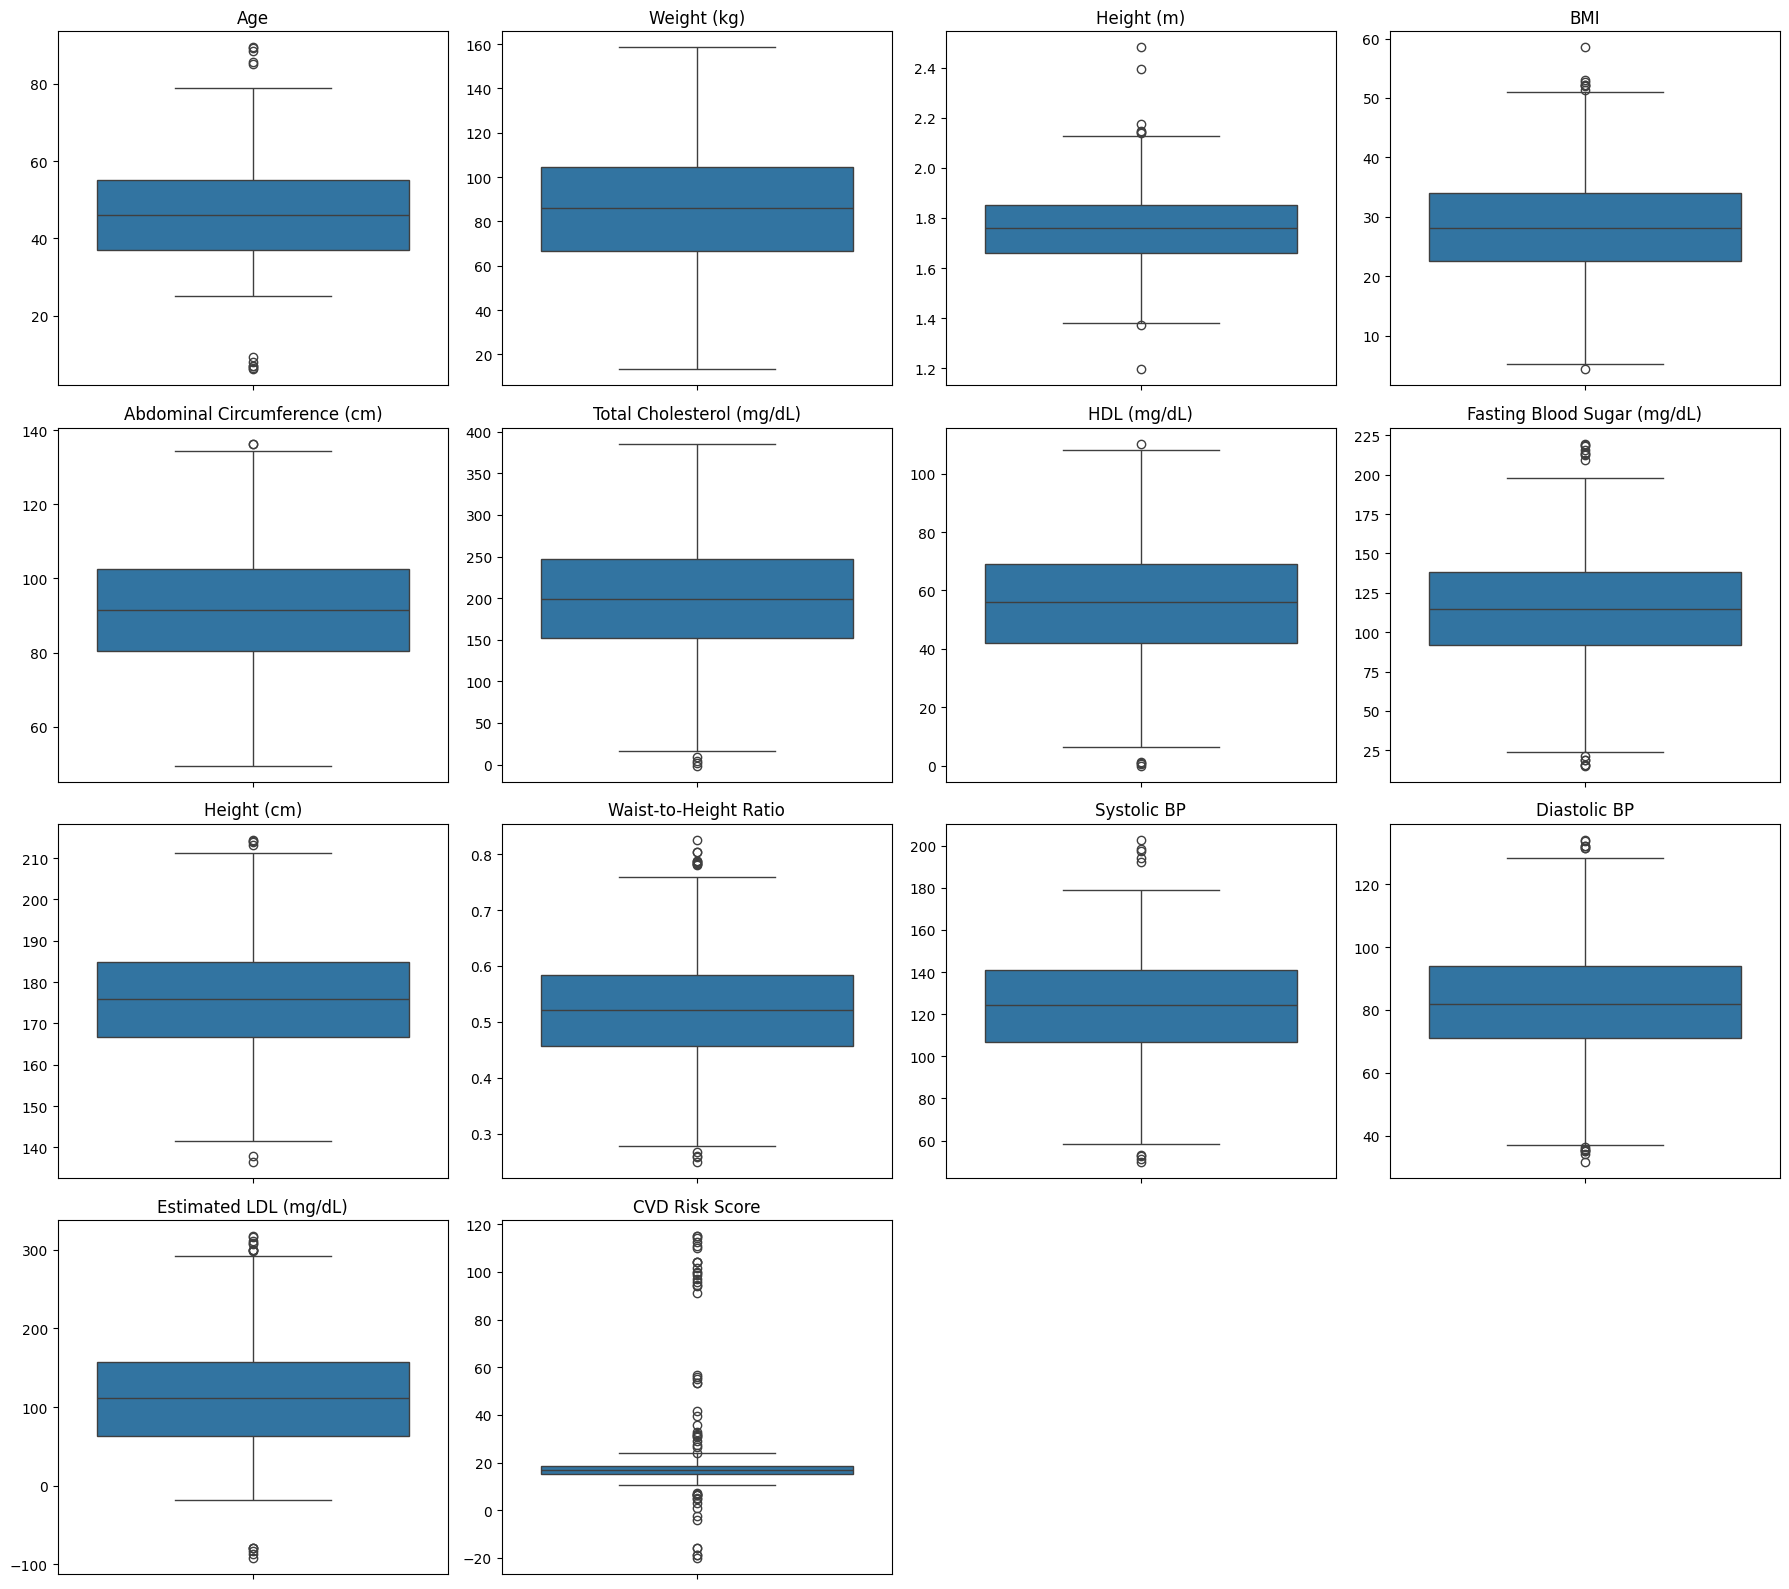

In [32]:
# Seleccionar columnas numéricas
num_cols = datos.select_dtypes(include="number").columns

# Definir tamaño del grid
n_cols = 4  # número de gráficos por fila
n_rows = math.ceil(len(num_cols) / n_cols)

# Crear figura
plt.figure(figsize=(18, 4 * n_rows))

# Crear un boxplot por variable
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=datos[col])
    plt.title(col)
    plt.ylabel("")
    
plt.tight_layout()
plt.show()

#### Detección exhaustiva + corrección

##### Asegurar tipos numéricos

In [33]:
# Columnas numéricas esperadas
num_cols = [
    "Age","Weight (kg)","Height (m)","BMI","Abdominal Circumference (cm)",
    "Total Cholesterol (mg/dL)","HDL (mg/dL)","Fasting Blood Sugar (mg/dL)",
    "Height (cm)","Waist-to-Height Ratio","Systolic BP","Diastolic BP",
    "Estimated LDL (mg/dL)","CVD Risk Score"
]

for c in num_cols:
    if c in datos.columns:
        datos[c] = pd.to_numeric(datos[c], errors="coerce")

##### Normalizar strings

In [34]:
str_cols = [
    "Patient ID","Sex","Smoking Status","Diabetes Status","Physical Activity Level",
    "Family History of CVD","Blood Pressure (mmHg)","Blood Pressure Category",
    "CVD Risk Level"
]
for c in str_cols:
    if c in datos.columns:
        datos[c] = datos[c].astype("string").str.strip()

##### Reglas de rango y marcar como inválido

In [35]:
# Reglas de rango (min, max)
ranges = {
    "Age": (0, 120),
    "Weight (kg)": (0, 300),
    "Height (m)": (1.20, 2.30),
    "Height (cm)": (120, 230),
    "BMI": (10, 80),
    "Abdominal Circumference (cm)": (40, 200),
    "Waist-to-Height Ratio": (0.20, 0.90),
    "Systolic BP": (70, 250),
    "Diastolic BP": (40, 150),
    "Total Cholesterol (mg/dL)": (70, 400),
    "HDL (mg/dL)": (10, 150),
    "Fasting Blood Sugar (mg/dL)": (40, 400),
    "Estimated LDL (mg/dL)": (0, 300),
    "CVD Risk Score": (0, 100)  # Más de 100 no tiene sentido
}

invalid_counts = {}

for col, (lo, hi) in ranges.items():
    if col not in datos.columns:
        continue
    m = datos[col].notna() & ((datos[col] < lo) | (datos[col] > hi))
    invalid_counts[col] = int(m.sum())
    # Marca inválidos como NaN (para luego imputar)
    datos.loc[m, col] = np.nan

invalid_counts

{'Age': 0,
 'Weight (kg)': 0,
 'Height (m)': 3,
 'Height (cm)': 0,
 'BMI': 4,
 'Abdominal Circumference (cm)': 0,
 'Waist-to-Height Ratio': 0,
 'Systolic BP': 5,
 'Diastolic BP': 9,
 'Total Cholesterol (mg/dL)': 7,
 'HDL (mg/dL)': 7,
 'Fasting Blood Sugar (mg/dL)': 7,
 'Estimated LDL (mg/dL)': 23,
 'CVD Risk Score': 17}

##### Después de marcar como inválidos volvemos a completitud

In [36]:
cols_mediana = [
    "Age",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Estimated LDL (mg/dL)",
    "CVD Risk Score"
]

for col in cols_mediana:
    if col in datos.columns:
        datos[col] = datos[col].fillna(datos[col].median())
        
cat_cols_moda = ["Sex","Smoking Status","Diabetes Status","Family History of CVD","Physical Activity Level","CVD Risk Level"]

for col in cat_cols_moda:
    if col in datos.columns and datos[col].isna().any():
        datos[col] = datos[col].fillna(datos[col].mode(dropna=True).iloc[0])

In [37]:
# ===============================
# 1. Completar Height (m) desde Height (cm)
# ===============================
cond_h = datos["Height (m)"].isna() & datos["Height (cm)"].notna()

datos.loc[cond_h, "Height (m)"] = (
    datos.loc[cond_h, "Height (cm)"] / 100
)

# ===============================
# 2. Completar BMI usando fórmula
# ===============================
cond_bmi = (
    datos["BMI"].isna() &
    datos["Weight (kg)"].notna() &
    datos["Height (m)"].notna()
)

datos.loc[cond_bmi, "BMI"] = (
    datos.loc[cond_bmi, "Weight (kg)"] /
    (datos.loc[cond_bmi, "Height (m)"]**2)
)

# ===============================
# 3. Recuperar presión arterial desde string
# ===============================
bp = datos["Blood Pressure (mmHg)"].str.split("/", expand=True)

# Systolic
cond_sys = datos["Systolic BP"].isna() & bp[0].notna()
datos.loc[cond_sys, "Systolic BP"] = bp.loc[cond_sys, 0].astype(float)

# Diastolic
cond_dia = datos["Diastolic BP"].isna() & bp[1].notna()
datos.loc[cond_dia, "Diastolic BP"] = bp.loc[cond_dia, 1].astype(float)

# ===============================
# 4. Imputación final con mediana (solo si aún queda algo)
# ===============================
cols_final = ["Height (m)", "BMI", "Systolic BP", "Diastolic BP"]

for col in cols_final:
    datos[col] = datos[col].fillna(datos[col].median())

# ===============================
# 5. Verificación final
# ===============================
print("Faltantes restantes:")
print(datos[cols_final].isna().sum())

Faltantes restantes:
Height (m)      0
BMI             0
Systolic BP     0
Diastolic BP    0
dtype: int64


### Consistencia

#### Heatmap de correlación

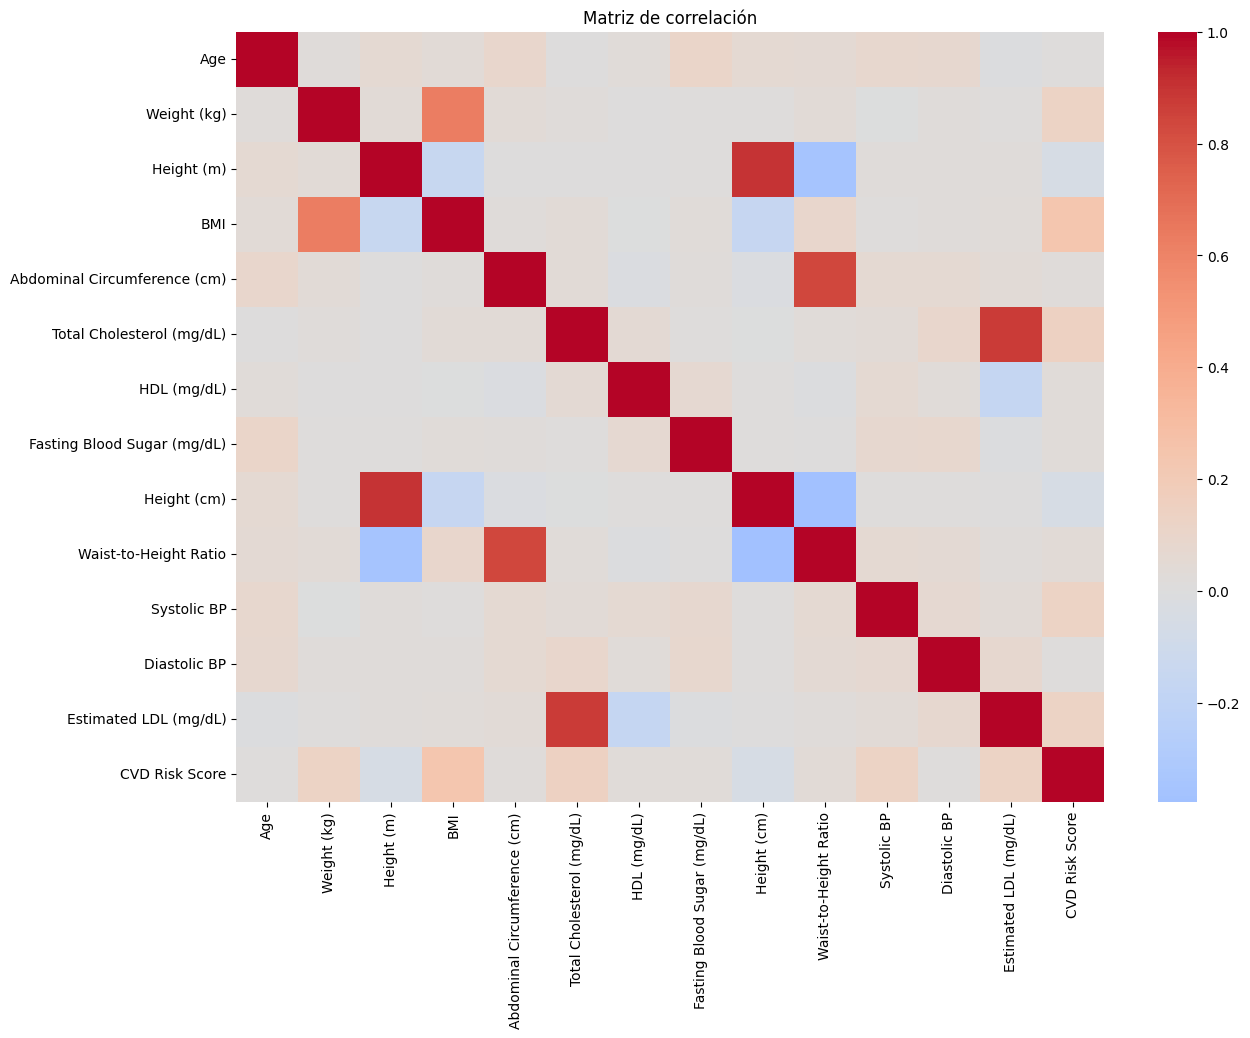

In [38]:
plt.figure(figsize=(14,10))
sns.heatmap(datos.corr(numeric_only=True),
            cmap="coolwarm",
            center=0,
            annot=False)

plt.title("Matriz de correlación")
plt.show()

#### Revisamos consistencia entre Height (m) y (cm)

In [39]:
((datos["Height (m)"]*100 - datos["Height (cm)"]).abs() > 1).sum()

np.int64(34)

Corregimos

In [40]:
datos["Height (cm)"] = datos["Height (m)"] * 100

#### Revisamos consistencia entre BMI, Weight (kg) y Height (m)

In [41]:
bmi_check = datos["Weight (kg)"]/(datos["Height (m)"]**2)

(abs(datos["BMI"] - bmi_check) > 0.1).sum()

np.int64(445)

Recalculamos el BMI

In [42]:
datos["BMI"] = datos["Weight (kg)"] / (datos["Height (m)"]**2)

Eliminamos los registros con BMI fuera del rango válido

In [43]:
# eliminar registros con BMI fuera de rango válido
datos = datos[(datos["BMI"] >= 10) & (datos["BMI"] <= 80)]

print("Nuevo tamaño del dataset:", datos.shape)

Nuevo tamaño del dataset: (1363, 24)


#### Revisamos consistencia entre Systolic BP y Diastolic BP

In [44]:
# 1. Detectar inconsistencias médicas
mask_bp = datos["Systolic BP"] < datos["Diastolic BP"]
print("Inconsistencias iniciales:", mask_bp.sum())

# 2. Extraer valores desde la fuente original
bp = datos["Blood Pressure (mmHg)"].astype("string").str.split("/", expand=True)

bp_sys = pd.to_numeric(bp[0], errors="coerce")
bp_dia = pd.to_numeric(bp[1], errors="coerce")

# 3. Reconstruir SOLO registros inconsistentes
datos.loc[mask_bp, "Systolic BP"] = bp_sys.loc[mask_bp]
datos.loc[mask_bp, "Diastolic BP"] = bp_dia.loc[mask_bp]

# 4. Revisar nuevamente
mask_bp = datos["Systolic BP"] < datos["Diastolic BP"]

# 5. Si aún quedan inconsistencias → invalidar e imputar
datos.loc[mask_bp, ["Systolic BP", "Diastolic BP"]] = np.nan

datos["Systolic BP"] = datos["Systolic BP"].fillna(datos["Systolic BP"].median())
datos["Diastolic BP"] = datos["Diastolic BP"].fillna(datos["Diastolic BP"].median())

# 6. Validación final
print("Inconsistencias finales:",
      (datos["Systolic BP"] < datos["Diastolic BP"]).sum())

Inconsistencias iniciales: 57
Inconsistencias finales: 0


#### Revalidación

In [45]:
print("Height inconsistentes:",
      ((datos["Height (m)"]*100 - datos["Height (cm)"]).abs() > 1).sum())

print("BMI inconsistentes:",
      (abs(datos["BMI"] -
           datos["Weight (kg)"]/(datos["Height (m)"]**2)) > 0.1).sum())

print("Presión arterial inconsistente:",
      (datos["Systolic BP"] < datos["Diastolic BP"]).sum())

Height inconsistentes: 0
BMI inconsistentes: 0
Presión arterial inconsistente: 0


### Verificación final

In [46]:
print("========== AUDITORÍA FINAL DE CALIDAD ==========\n")

# =================================================
# 1. COMPLETITUD
# =================================================
faltantes_totales = datos.isna().sum().sum()

print("COMPLETITUD")
print("Faltantes totales:", faltantes_totales)
print("Estado:", "✅ OK" if faltantes_totales == 0 else "❌ Hay faltantes")
print()

# =================================================
# 2. UNICIDAD
# =================================================
dup_exactos = datos.duplicated().sum()

dup_logicos = datos.duplicated(
    subset=["Patient ID", "Date of Service"]
).sum()

print("UNICIDAD")
print("Duplicados exactos:", dup_exactos)
print("Duplicados (Patient ID + Date):", dup_logicos)
print("Estado:", "✅ OK" if dup_exactos == 0 and dup_logicos == 0 else "❌ Hay duplicados")
print()

# =================================================
# 3. VALIDEZ (NUEVOS RANGOS)
# =================================================
ranges = {
    "Age": (0, 120),
    "Weight (kg)": (0, 300),
    "Height (m)": (1.20, 2.30),
    "Height (cm)": (120, 230),
    "BMI": (10, 80),
    "Abdominal Circumference (cm)": (40, 200),
    "Waist-to-Height Ratio": (0.20, 0.90),
    "Systolic BP": (70, 250),
    "Diastolic BP": (40, 150),
    "Total Cholesterol (mg/dL)": (70, 400),
    "HDL (mg/dL)": (10, 150),
    "Fasting Blood Sugar (mg/dL)": (40, 400),
    "Estimated LDL (mg/dL)": (0, 300),
    "CVD Risk Score": (0, np.inf)
}

invalid_validez = {}

for col, (lo, hi) in ranges.items():
    if col in datos.columns:
        invalid_validez[col] = int(
            ((datos[col] < lo) | (datos[col] > hi)).sum()
        )

total_invalid = sum(invalid_validez.values())

print("VALIDEZ")
print("Valores fuera de rango:", total_invalid)
print("Detalle:", invalid_validez)
print("Estado:", "✅ OK" if total_invalid == 0 else "❌ Hay valores inválidos")
print()

# =================================================
# 4. CONSISTENCIA
# =================================================
height_incons = ((datos["Height (m)"]*100 - datos["Height (cm)"]).abs() > 1).sum()

bmi_calc = datos["Weight (kg)"]/(datos["Height (m)"]**2)
bmi_incons = (abs(datos["BMI"] - bmi_calc) > 0.1).sum()

bp_incons = (datos["Systolic BP"] < datos["Diastolic BP"]).sum()

print("CONSISTENCIA")
print("Height inconsistentes:", int(height_incons))
print("BMI inconsistentes:", int(bmi_incons))
print("BP inconsistentes:", int(bp_incons))

consistencia_ok = (height_incons == 0 and bmi_incons == 0 and bp_incons == 0)

print("Estado:", "✅ OK" if consistencia_ok else "❌ Hay inconsistencias")
print()

# =================================================
# RESULTADO FINAL
# =================================================
if (
    faltantes_totales == 0
    and dup_exactos == 0
    and dup_logicos == 0
    and total_invalid == 0
    and consistencia_ok
):
    print("🎉 DATASET COMPLETAMENTE LIMPIO Y VALIDADO")
else:
    print("⚠️ Aún existen problemas de calidad de datos")

========== AUDITORÍA FINAL DE CALIDAD ==========

COMPLETITUD
Faltantes totales: 0
Estado: ✅ OK

UNICIDAD
Duplicados exactos: 0
Duplicados (Patient ID + Date): 0
Estado: ✅ OK

VALIDEZ
Valores fuera de rango: 0
Detalle: {'Age': 0, 'Weight (kg)': 0, 'Height (m)': 0, 'Height (cm)': 0, 'BMI': 0, 'Abdominal Circumference (cm)': 0, 'Waist-to-Height Ratio': 0, 'Systolic BP': 0, 'Diastolic BP': 0, 'Total Cholesterol (mg/dL)': 0, 'HDL (mg/dL)': 0, 'Fasting Blood Sugar (mg/dL)': 0, 'Estimated LDL (mg/dL)': 0, 'CVD Risk Score': 0}
Estado: ✅ OK

CONSISTENCIA
Height inconsistentes: 0
BMI inconsistentes: 0
BP inconsistentes: 0
Estado: ✅ OK

🎉 DATASET COMPLETAMENTE LIMPIO Y VALIDADO


## 2. Transformación de los datos

Ya se hizo la limpieza necesaria en términos de completitud, unicidad validez y consistencia. Sin embargo, aún es necesario transformar los datos para que se puedan usar en el modelo de regresión lineal.

Primero, se va a determinar la codificación de variables categóricas, pues estas constituyen una parte importante de los datos. Se pueden identificar los siguientes datos categóricos:
- Sex
- Smoking Status
- Diabetes Status
- Physical Activity Level
- Family of History of CVD
- Blood Pressure Category
- CVD Risk Level

In [47]:
datos_transformados = datos.copy()

Se va a empezar con la transformación de las variables categóricas que tienen valores booleanos. Estas son Sex, Smoking Status, Diabetes Status y Family History of CVD. Vale la pena mencionar que a pesa de que en el diccionario se muestra que Sex es un String, pero como tiene solo 2 posibles valores, se puede considerar como booleana. 

A estas variables simplemente se les asignara un 0 o un 1 dependiendo de su valor.

Para Smoking Status, Diabetes Status y Family History of CVD:

Y = 0
N = 1

Para Sex:

M = 0
F = 1

In [48]:
print(datos_transformados["Sex"].value_counts())
print()
print(datos_transformados["Smoking Status"].value_counts())
print()
print(datos_transformados["Diabetes Status"].value_counts())
print()
print(datos_transformados["Family History of CVD"].value_counts())

Sex
F    691
M    672
Name: count, dtype: Int64

Smoking Status
Y    705
N    658
Name: count, dtype: Int64

Diabetes Status
Y    694
N    669
Name: count, dtype: Int64

Family History of CVD
N    695
Y    668
Name: count, dtype: Int64


In [49]:
# Encoders para las variables con el orden deseado
encoder_sex = OrdinalEncoder(categories=[['M', 'F']])
encoder_otros = OrdinalEncoder(categories=[['N', 'Y']])

In [50]:
datos_transformados['Sex'] = encoder_sex.fit_transform(datos_transformados[['Sex']]).astype(int)
datos_transformados['Smoking Status'] = encoder_otros.fit_transform(datos_transformados[['Smoking Status']]).astype(int)
datos_transformados['Diabetes Status'] = encoder_otros.fit_transform(datos_transformados[['Diabetes Status']]).astype(int)
datos_transformados['Family History of CVD'] = encoder_otros.fit_transform(datos_transformados[['Family History of CVD']]).astype(int)

In [51]:
print(datos_transformados["Sex"].value_counts())
print()
print(datos_transformados["Smoking Status"].value_counts())
print()
print(datos_transformados["Diabetes Status"].value_counts())
print()
print(datos_transformados["Family History of CVD"].value_counts())

Sex
1    691
0    672
Name: count, dtype: int64

Smoking Status
1    705
0    658
Name: count, dtype: int64

Diabetes Status
1    694
0    669
Name: count, dtype: int64

Family History of CVD
0    695
1    668
Name: count, dtype: int64


Las otras variables categóricas no son binarias:

In [52]:
print(datos_transformados["Physical Activity Level"].value_counts())
print()
print(datos_transformados["Blood Pressure Category"].value_counts())
print()
print(datos_transformados["CVD Risk Level"].value_counts())

Physical Activity Level
High        465
Moderate    457
Low         441
Name: count, dtype: Int64

Blood Pressure Category
Hypertension Stage 2    561
Hypertension Stage 1    448
Normal                  264
Elevated                 90
Name: count, dtype: Int64

CVD Risk Level
HIGH            650
INTERMEDIARY    515
LOW             198
Name: count, dtype: Int64


Existe un orden jerárquico natural dentro de estas variables. Por esto, se les pueden asignar valores numéricos a estas categorías ya que siguen un orden lógico.

In [53]:
# Encoders para las variables con el orden deseado
encoder_actividad = OrdinalEncoder(categories=[['Low', 'Moderate', 'High']])
encoder_presion = OrdinalEncoder(categories=[['Normal', 'Elevated', 'Hypertension Stage 1', 'Hypertension Stage 2']])
encoder_nivel = OrdinalEncoder(categories=[['LOW', 'INTERMEDIARY', 'HIGH']])

In [54]:
datos_transformados['Physical Activity Level'] = encoder_actividad.fit_transform(datos_transformados[['Physical Activity Level']]).astype(int)
datos_transformados['Blood Pressure Category'] = encoder_presion.fit_transform(datos_transformados[['Blood Pressure Category']]).astype(int)
datos_transformados['CVD Risk Level'] = encoder_nivel.fit_transform(datos_transformados[['CVD Risk Level']]).astype(int)

In [55]:
print(datos_transformados["Physical Activity Level"].value_counts())
print()
print(datos_transformados["Blood Pressure Category"].value_counts())
print()
print(datos_transformados["CVD Risk Level"].value_counts())

Physical Activity Level
2    465
1    457
0    441
Name: count, dtype: int64

Blood Pressure Category
3    561
2    448
0    264
1     90
Name: count, dtype: int64

CVD Risk Level
2    650
1    515
0    198
Name: count, dtype: int64


Ahora que los datos categóricos pueden ser analizados numéricamente, se pueden llevar las variables que se van a usar para el modelo a una escala común. Como las variables varían mucho y tienen rangos muy diferentes, se decidió que estas se van a estandarizar. 

No todas las variables deben ser estandarizadas. Unas variables no tienen sentido si se estandarizan. Por ejemplo, la fecha. Otras variables no tienen sentido usar. Por ejemplo, si se usa Waist-to-Height Ratio, no es necesaro usar Abdominal Circumference o Altura. Otro ejemplo es CVD Risk Level, que este viede de la variable objetivo CVD Risk Score.

A continuación se va a crear un dataframe con solo las variables que van a ser utilizadas para el modelo.

In [56]:
datos_para_modelo = datos_transformados.copy()

columnas_eliminar = [
    "Patient ID",
    "Date of Service",
    "CVD Risk Level",
    "Blood Pressure (mmHg)",
    "Height (cm)",
    "Weight (kg)",
    "Height (m)",
    "Abdominal Circumference (cm)",
    "Blood Pressure Category"
]

datos_para_modelo = datos_para_modelo.drop(columns=columnas_eliminar)

In [57]:
datos_para_modelo.info()

<class 'pandas.DataFrame'>
Index: 1363 entries, 0 to 1638
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sex                          1363 non-null   int64  
 1   Age                          1363 non-null   float64
 2   BMI                          1363 non-null   float64
 3   Total Cholesterol (mg/dL)    1363 non-null   float64
 4   HDL (mg/dL)                  1363 non-null   float64
 5   Fasting Blood Sugar (mg/dL)  1363 non-null   float64
 6   Smoking Status               1363 non-null   int64  
 7   Diabetes Status              1363 non-null   int64  
 8   Physical Activity Level      1363 non-null   int64  
 9   Family History of CVD        1363 non-null   int64  
 10  Waist-to-Height Ratio        1363 non-null   float64
 11  Systolic BP                  1363 non-null   float64
 12  Diastolic BP                 1363 non-null   float64
 13  Estimated LDL (mg/dL)        1363 

Para escalar, es necesario definir X y Y del modelo. Además, solo se deben estandarizar las variables numéricas continuas. 

In [58]:
from sklearn.model_selection import train_test_split

target = "CVD Risk Score"

# Separar variables predictoras (X) y variable objetivo (y)
X = datos_para_modelo.drop(columns=[target])
y = datos_para_modelo[target]

# División 75% entrenamiento / 25% prueba (similar al lab de Regresión Lineal)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
)


In [59]:
columnas_continuas = [
    "Age",
    "BMI",
    "Waist-to-Height Ratio",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Systolic BP",
    "Diastolic BP"
]

scaler = StandardScaler()

# Ajustar SOLO con entrenamiento y transformar ambos conjuntos (train/test)
X_train[columnas_continuas] = scaler.fit_transform(X_train[columnas_continuas])
X_test[columnas_continuas] = scaler.transform(X_test[columnas_continuas])


In [60]:
X_train

,Sex,Age,BMI,Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL)
836,1,0.473066,0.727970,-0.446051,-1.145902,1.429979,1,1,2,1,1.310672,0.756189,-1.064629,-0.116202
265,0,0.160217,1.353131,-0.786943,0.948599,-0.246988,0,1,1,0,1.275836,-0.036756,-0.059500,-1.049821
77,0,-0.074420,-1.077888,1.473708,0.123493,-0.148343,0,0,2,0,-1.731715,-1.482715,0.299474,1.445816
240,0,0.394853,0.375420,1.563416,1.012069,1.068280,0,1,0,1,-0.767905,-1.389427,0.730244,1.284228
1163,0,-0.465481,2.584013,0.163966,0.821660,-1.101913,0,1,1,1,-0.605335,1.595778,0.730244,-0.062339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
803,1,-1.482240,-0.096224,1.760775,1.583297,0.969635,0,1,2,0,-1.278840,1.968928,0.945628,1.320136
1055,1,0.473066,-1.114774,0.002491,1.075539,0.377764,0,1,2,0,-0.675008,-0.269975,-1.064629,-0.295744
1289,1,1.333400,-1.158349,0.253674,0.123493,-1.101913,1,1,1,1,1.124878,2.248791,-0.921039,0.224929
247,1,-0.465481,0.180789,1.025166,1.075539,0.542173,1,1,0,0,-1.418186,0.989408,-1.064629,0.727647


In [61]:
y_train

836     19.715
265     17.420
77      14.270
240     18.123
1163    18.993
         ...  
803     22.642
1055    15.870
1289    16.951
247     20.440
1246    15.260
Name: CVD Risk Score, Length: 1022, dtype: float64

## 3. Construcción del pipeline de preparación de datos

En esta sección se encapsula **todo el proceso de limpieza + transformación + escalado** en un **pipeline reutilizable**.
No se cambia la lógica del proceso. Los pasos aplicados dentro del pipeline replican exactamente las mismas operaciones realizadas previamente sobre los datos.


In [62]:
def limpiar_datos_pacientes(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica EXACTAMENTE las mismas reglas de limpieza definidas en el notebook,
    pero encapsuladas en una sola función para reutilizarse dentro de un pipeline.
    """
    datos = df.copy()

    # =================================================
    # COMPLETITUD: imputaciones determinísticas
    # =================================================
    # BMI, Height (m) y Weight (kg)
    condicion = (
        datos["Height (m)"].isna() &
        datos["Weight (kg)"].notna() &
        datos["BMI"].notna()
    )
    datos.loc[condicion, "Height (m)"] = np.sqrt(
        datos.loc[condicion, "Weight (kg)"] /
        datos.loc[condicion, "BMI"]
    )

    condicion_weight = (
        datos["Weight (kg)"].isna() &
        datos["Height (m)"].notna() &
        datos["BMI"].notna()
    )
    datos.loc[condicion_weight, "Weight (kg)"] = (
        datos.loc[condicion_weight, "BMI"] *
        datos.loc[condicion_weight, "Height (m)"]**2
    )

    condicion_bmi = (
        datos["BMI"].isna() &
        datos["Weight (kg)"].notna() &
        datos["Height (m)"].notna()
    )
    datos.loc[condicion_bmi, "BMI"] = (
        datos.loc[condicion_bmi, "Weight (kg)"] /
        (datos.loc[condicion_bmi, "Height (m)"]**2)
    )

    # Borrar filas con faltantes (tras las correcciones)
    datos = datos.dropna(subset=["Weight (kg)", "Height (m)", "BMI"])

    # Height (m) <-> Height (cm)
    cond_cm = datos["Height (cm)"].isna() & datos["Height (m)"].notna()
    datos.loc[cond_cm, "Height (cm)"] = (
        datos.loc[cond_cm, "Height (m)"] * 100
    )

    cond_m = datos["Height (m)"].isna() & datos["Height (cm)"].notna()
    datos.loc[cond_m, "Height (m)"] = (
        datos.loc[cond_m, "Height (cm)"] / 100
    )

    # Waist-to-Height Ratio
    cond_whr = (
        datos["Waist-to-Height Ratio"].isna() &
        datos["Abdominal Circumference (cm)"].notna() &
        datos["Height (cm)"].notna()
    )
    datos.loc[cond_whr, "Waist-to-Height Ratio"] = (
        datos.loc[cond_whr, "Abdominal Circumference (cm)"] /
        datos.loc[cond_whr, "Height (cm)"]
    )

    # Abdominal Circumference (cm)
    cond_abd = (
        datos["Waist-to-Height Ratio"].notna() &
        datos["Abdominal Circumference (cm)"].isna() &
        datos["Height (cm)"].notna()
    )
    datos.loc[cond_abd, "Abdominal Circumference (cm)"] = (
        datos.loc[cond_abd, "Waist-to-Height Ratio"] *
        datos.loc[cond_abd, "Height (cm)"]
    )

    # Borrar filas con faltantes restantes
    datos = datos.dropna(subset=["Waist-to-Height Ratio", "Abdominal Circumference (cm)", "Height (cm)"])

    # Blood Pressure (mmHg) -> Systolic / Diastolic (si aplica)
    bp_split = datos["Blood Pressure (mmHg)"].str.split("/", expand=True)

    cond_sys = (
        datos["Systolic BP"].isna() &
        datos["Blood Pressure (mmHg)"].notna()
    )
    datos.loc[cond_sys, "Systolic BP"] = bp_split.loc[cond_sys, 0].astype(float)

    cond_dia = (
        datos["Diastolic BP"].isna() &
        datos["Blood Pressure (mmHg)"].notna()
    )
    datos.loc[cond_dia, "Diastolic BP"] = bp_split.loc[cond_dia, 1].astype(float)

    # =================================================
    # IMPUTACIÓN ESTADÍSTICA (mediana) - primera pasada
    # =================================================
    cols_mediana = [
        "Age",
        "Total Cholesterol (mg/dL)",
        "HDL (mg/dL)",
        "Fasting Blood Sugar (mg/dL)",
        "Estimated LDL (mg/dL)",
        "CVD Risk Score"
    ]
    for col in cols_mediana:
        datos[col] = datos[col].fillna(datos[col].median())

    # =================================================
    # UNICIDAD: duplicados exactos y por clave
    # =================================================
    datos = datos.drop_duplicates()

    datos["Date of Service"] = pd.to_datetime(
        datos["Date of Service"],
        format="mixed",   # permite múltiples formatos
        dayfirst=True,    # interpreta correctamente DD/MM/YYYY
        errors="coerce"   # valores inválidos → NaT
    )

    datos = datos.drop_duplicates(
        subset=["Patient ID", "Date of Service"]
    )

    # =================================================
    # VALIDEZ: asegurar tipos + normalizar strings + rangos
    # =================================================
    # 1) Tipos numéricos
    num_cols = [
        "Age","Weight (kg)","Height (m)","BMI","Abdominal Circumference (cm)",
        "Total Cholesterol (mg/dL)","HDL (mg/dL)","Fasting Blood Sugar (mg/dL)",
        "Height (cm)","Waist-to-Height Ratio","Systolic BP","Diastolic BP",
        "Estimated LDL (mg/dL)","CVD Risk Score"
    ]
    for c in num_cols:
        if c in datos.columns:
            datos[c] = pd.to_numeric(datos[c], errors="coerce")

    # 2) Normalizar strings
    str_cols = [
        "Patient ID","Sex","Smoking Status","Diabetes Status","Physical Activity Level",
        "Family History of CVD","Blood Pressure (mmHg)","Blood Pressure Category",
        "CVD Risk Level"
    ]
    for c in str_cols:
        if c in datos.columns:
            datos[c] = datos[c].astype("string").str.strip()

    # 3) Reglas de rango y marcar como inválido (NaN)
    ranges = {
        "Age": (0, 120),
        "Weight (kg)": (0, 300),
        "Height (m)": (1.20, 2.30),
        "Height (cm)": (120, 230),
        "BMI": (10, 80),
        "Abdominal Circumference (cm)": (40, 200),
        "Waist-to-Height Ratio": (0.20, 0.90),
        "Systolic BP": (70, 250),
        "Diastolic BP": (40, 150),
        "Total Cholesterol (mg/dL)": (70, 400),
        "HDL (mg/dL)": (10, 150),
        "Fasting Blood Sugar (mg/dL)": (40, 400),
        "Estimated LDL (mg/dL)": (0, 300),
        "CVD Risk Score": (0, 100)  # Más de 100 no tiene sentido
    }

    for col, (lo, hi) in ranges.items():
        if col not in datos.columns:
            continue
        m = datos[col].notna() & ((datos[col] < lo) | (datos[col] > hi))
        # Marca inválidos como NaN (para luego imputar)
        datos.loc[m, col] = np.nan

    # =================================================
    # VOLVER A COMPLETITUD DESPUÉS DE INVALIDAR
    # =================================================
    cols_mediana = [
        "Age",
        "Total Cholesterol (mg/dL)",
        "HDL (mg/dL)",
        "Fasting Blood Sugar (mg/dL)",
        "Estimated LDL (mg/dL)",
        "CVD Risk Score"
    ]
    for col in cols_mediana:
        datos[col] = datos[col].fillna(datos[col].median())

    cat_cols_moda = ["Sex","Smoking Status","Diabetes Status","Family History of CVD","Physical Activity Level","CVD Risk Level"]
    for col in cat_cols_moda:
        if col in datos.columns and datos[col].isna().any():
            datos[col] = datos[col].fillna(datos[col].mode(dropna=True).iloc[0])

    # =================================================
    # RECUPERACIONES + IMPUTACIÓN FINAL (tal cual el notebook)
    # =================================================
    # 1. Completar Height (m) desde Height (cm)
    cond_h = datos["Height (m)"].isna() & datos["Height (cm)"].notna()
    datos.loc[cond_h, "Height (m)"] = (
        datos.loc[cond_h, "Height (cm)"] / 100
    )

    # 2. Completar BMI usando fórmula
    cond_bmi = (
        datos["BMI"].isna() &
        datos["Weight (kg)"].notna() &
        datos["Height (m)"].notna()
    )
    datos.loc[cond_bmi, "BMI"] = (
        datos.loc[cond_bmi, "Weight (kg)"] /
        (datos.loc[cond_bmi, "Height (m)"]**2)
    )

    # 3. Recuperar presión arterial desde string
    bp = datos["Blood Pressure (mmHg)"].str.split("/", expand=True)

    cond_sys = datos["Systolic BP"].isna() & bp[0].notna()
    datos.loc[cond_sys, "Systolic BP"] = bp.loc[cond_sys, 0].astype(float)

    cond_dia = datos["Diastolic BP"].isna() & bp[1].notna()
    datos.loc[cond_dia, "Diastolic BP"] = bp.loc[cond_dia, 1].astype(float)

    # 4. Imputación final con mediana (solo si aún queda algo)
    cols_final = ["Height (m)", "BMI", "Systolic BP", "Diastolic BP"]
    for col in cols_final:
        datos[col] = datos[col].fillna(datos[col].median())

    # =================================================
    # CONSISTENCIA: correcciones finales tal cual el notebook
    # =================================================
    # Height (cm) coherente con Height (m)
    datos["Height (cm)"] = datos["Height (m)"] * 100

    # Recalcular BMI y filtrar fuera de rango válido
    datos["BMI"] = datos["Weight (kg)"] / (datos["Height (m)"]**2)
    datos = datos[(datos["BMI"] >= 10) & (datos["BMI"] <= 80)]

    # Systolic BP vs Diastolic BP
    mask_bp = datos["Systolic BP"] < datos["Diastolic BP"]

    bp = datos["Blood Pressure (mmHg)"].astype("string").str.split("/", expand=True)
    bp_sys = pd.to_numeric(bp[0], errors="coerce")
    bp_dia = pd.to_numeric(bp[1], errors="coerce")

    datos.loc[mask_bp, "Systolic BP"] = bp_sys.loc[mask_bp]
    datos.loc[mask_bp, "Diastolic BP"] = bp_dia.loc[mask_bp]

    mask_bp = datos["Systolic BP"] < datos["Diastolic BP"]
    datos.loc[mask_bp, ["Systolic BP", "Diastolic BP"]] = np.nan

    datos["Systolic BP"] = datos["Systolic BP"].fillna(datos["Systolic BP"].median())
    datos["Diastolic BP"] = datos["Diastolic BP"].fillna(datos["Diastolic BP"].median())

    return datos


In [63]:
def transformar_datos_pacientes(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica EXACTAMENTE las mismas transformaciones del notebook:
    - Ordinal encoding con el orden definido
    - Eliminación de columnas no usadas para el modelo
    Retorna un DataFrame listo para separar en X/y (incluye el target).
    """
    datos_transformados = df.copy()

    # Variables categóricas binarias
    encoder_sex = OrdinalEncoder(categories=[['M', 'F']])
    encoder_otros = OrdinalEncoder(categories=[['N', 'Y']])

    datos_transformados['Sex'] = encoder_sex.fit_transform(datos_transformados[['Sex']]).astype(int)
    datos_transformados['Smoking Status'] = encoder_otros.fit_transform(datos_transformados[['Smoking Status']]).astype(int)
    datos_transformados['Diabetes Status'] = encoder_otros.fit_transform(datos_transformados[['Diabetes Status']]).astype(int)
    datos_transformados['Family History of CVD'] = encoder_otros.fit_transform(datos_transformados[['Family History of CVD']]).astype(int)

    # Variables categóricas ordinales
    encoder_actividad = OrdinalEncoder(categories=[['Low', 'Moderate', 'High']])
    encoder_presion = OrdinalEncoder(categories=[['Normal', 'Elevated', 'Hypertension Stage 1', 'Hypertension Stage 2']])
    encoder_nivel = OrdinalEncoder(categories=[['LOW', 'INTERMEDIARY', 'HIGH']])

    datos_transformados['Physical Activity Level'] = encoder_actividad.fit_transform(datos_transformados[['Physical Activity Level']]).astype(int)
    datos_transformados['Blood Pressure Category'] = encoder_presion.fit_transform(datos_transformados[['Blood Pressure Category']]).astype(int)
    datos_transformados['CVD Risk Level'] = encoder_nivel.fit_transform(datos_transformados[['CVD Risk Level']]).astype(int)

    # Eliminar columnas no usadas en el modelo
    datos_para_modelo = datos_transformados.copy()

    columnas_eliminar = [
        "Patient ID",
        "Date of Service",
        "CVD Risk Level",
        "Blood Pressure (mmHg)",
        "Height (cm)",
        "Weight (kg)",
        "Height (m)",
        "Abdominal Circumference (cm)",
        "Blood Pressure Category"
    ]

    datos_para_modelo = datos_para_modelo.drop(columns=columnas_eliminar)

    return datos_para_modelo


In [64]:
class EscaladorColumnas(BaseEstimator, TransformerMixin):
    """Estandariza únicamente las columnas continuas (mismo criterio del notebook),
    preservando nombres y orden de columnas.
    """
    def __init__(self, columnas_continuas):
        self.columnas_continuas = list(columnas_continuas)

    def fit(self, X, y=None):
        # atributo con "_" para que sklearn lo reconozca como "fitted"
        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.columnas_continuas])
        return self

    def transform(self, X):
        X_ = X.copy()
        X_[self.columnas_continuas] = self.scaler_.transform(X_[self.columnas_continuas])
        return X_

# Columnas continuas (exactamente como en el notebook)
columnas_continuas = [
    "Age",
    "BMI",
    "Waist-to-Height Ratio",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Systolic BP",
    "Diastolic BP"
]

pipeline_preparacion1 = Pipeline(steps=[
    ("limpieza", FunctionTransformer(limpiar_datos_pacientes, validate=False)),
    ("transformacion", FunctionTransformer(transformar_datos_pacientes, validate=False)),
    ("escalado", EscaladorColumnas(columnas_continuas)),
])

set_config(display="diagram")
pipeline_preparacion1


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('limpieza', ...), ('transformacion', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function lim...002441B2C8A40>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword argument

In [65]:
# ============================================================
# División 75% / 25% y aplicación del pipeline (similar a RegresiónLineal.ipynb)
# ============================================================
target = "CVD Risk Score"

def preparar_X_y(df: pd.DataFrame, pipeline: Pipeline, *, target_col: str, fit: bool = False):
    """Ejecuta el pipeline sobre un dataset y retorna X / y listos para modelado.
    - fit=True  -> usa fit_transform (para TRAIN)
    - fit=False -> usa transform (para TEST)
    """
    df_preparado = pipeline.fit_transform(df) if fit else pipeline.transform(df)
    X = df_preparado.drop(columns=[target_col])
    y = df_preparado[target_col]
    return X, y, df_preparado

# 1) Split 75/25 del dataset con etiqueta
datos_train, datos_test = train_test_split(
    datos_pacientes, test_size=0.25, random_state=1
)

# 2) Fit en TRAIN y transform en TEST
X_train, y_train, datos_train_preparados = preparar_X_y(
    datos_train, pipeline_preparacion1, target_col=target, fit=True
)

X_test, y_test, datos_test_preparados = preparar_X_y(
    datos_test, pipeline_preparacion1, target_col=target, fit=False
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape


((1068, 14), (1068,), (380, 14), (380,))

## 4. Entrenamiento de modelo de regresión lineal


In [66]:
Modelo1 = LinearRegression()

In [67]:
Modelo1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
y_train_pred = Modelo1.predict(X_train)

### Validación del modelo:

#### MAE

In [69]:
mae_train = mean_absolute_error(y_train, y_train_pred)
print("MAE  train:", mae_train)

MAE  train: 1.7813205342960108


#### RMSE

In [70]:
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
print("RMSE train:", rmse_train)

RMSE train: 6.121890651328198


#### R^2

In [71]:
r2_train = r2_score(y_train, y_train_pred)
print("R²   train:", r2_train)

R²   train: 0.11318358209179946


## 5. Estimación de la capacidad de generalización del modelo

In [72]:
y_test_pred = Modelo1.predict(X_test)

### Validación del modelo:

#### MAE

In [73]:
mae_test = mean_absolute_error(y_test, y_test_pred)
print("MAE  test:", mae_test)

MAE  test: 2.7052882181875306


#### RMSE

In [74]:
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
print("RMSE test:", rmse_test)

RMSE test: 9.250216618690668


#### R^2

In [75]:
r2_test = r2_score(y_test, y_test_pred)
print("R²   test:", r2_test)

R²   test: 0.010329469082555831


#### Intercepto:

In [76]:
print(Modelo1.intercept_)

15.742170721486982


#### Coeficientes:

In [77]:
feature_names = list(X_train.columns)
coefs = getattr(Modelo1, "coef_", None)
if coefs is None:
    print("Modelo1 no tiene atributo coef_")
else:
    if getattr(coefs, "ndim", 1) == 2 and coefs.shape[0] == 1:
        coefs = coefs.ravel()
    coef_df = pd.DataFrame({"Variable": feature_names, "Coeficiente": coefs})
    print(coef_df)

                       Variable  Coeficiente
0                           Sex     0.204895
1                           Age    -0.157182
2                           BMI     0.879444
3     Total Cholesterol (mg/dL)     0.990648
4                   HDL (mg/dL)     0.292433
5   Fasting Blood Sugar (mg/dL)    -0.053227
6                Smoking Status     0.485626
7               Diabetes Status     2.169438
8       Physical Activity Level     0.461828
9         Family History of CVD    -0.342285
10        Waist-to-Height Ratio    -0.133216
11                  Systolic BP     1.164201
12                 Diastolic BP    -0.061950
13        Estimated LDL (mg/dL)    -0.010450


# Segundo modelo